# Exploratory Data Analysis: Credit Risk Probability Model
## Xente eCommerce Transaction Dataset

**Building a Credit Risk Scoring Model for Bati Bank**

This notebook performs a thorough exploratory analysis of the Xente transaction dataset to:
- Understand the data structure, distributions, and quality issues
- Uncover patterns that inform feature engineering
- Form and document hypotheses about credit risk signals in the data


---

## Section 1: Import Libraries

In [22]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Data Overview and Summary Statistics

In [23]:
# Load the dataset
df = pd.read_csv('../data/raw/data.csv')

print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"Dataset Shape: {df.shape}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Customers: {df['CustomerId'].nunique():,}")
print(f"Total Accounts: {df['AccountId'].nunique():,}")
print(f"Total amount (sum): {df['Amount'].sum():>14,.2f}")

print(f"Fraud rate: {df['FraudResult'].mean()*100:>13.2f}%")
print(f"Avg transaction amount: {df['Amount'].mean():>14,.2f}")

print("\n" + "=" * 80)
print("DATA TYPES AND STRUCTURE")
print("=" * 80)
print(df.dtypes)

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
df.head()

DATASET OVERVIEW
Dataset Shape: (95662, 16)
Total Transactions: 95,662
Total Customers: 3,742
Total Accounts: 3,633
Total amount (sum): 642,642,625.50
Fraud rate:          0.20%
Avg transaction amount:       6,717.85

DATA TYPES AND STRUCTURE
TransactionId               str
BatchId                     str
AccountId                   str
SubscriptionId              str
CustomerId                  str
CurrencyCode                str
CountryCode               int64
ProviderId                  str
ProductId                   str
ProductCategory             str
ChannelId                   str
Amount                  float64
Value                     int64
TransactionStartTime        str
PricingStrategy           int64
FraudResult               int64
dtype: object

FIRST 5 ROWS


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


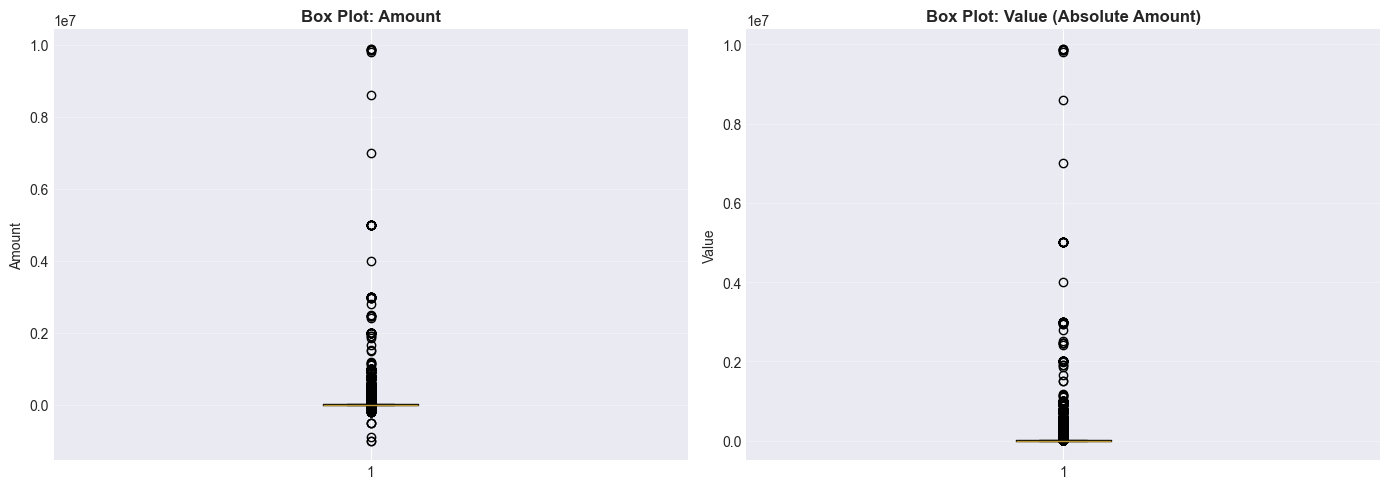

OUTLIER DETECTION - INTERQUARTILE RANGE (IQR) METHOD

Amount:
  IQR Bounds: [-4325.00, 7075.00]
  Outliers: 24441 (25.55%)

Value:
  IQR Bounds: [-6812.50, 12087.50]
  Outliers: 9021 (9.43%)

CountryCode:
  IQR Bounds: [256.00, 256.00]
  Outliers: 0 (0.00%)

PricingStrategy:
  IQR Bounds: [2.00, 2.00]
  Outliers: 15814 (16.53%)

FraudResult:
  IQR Bounds: [0.00, 0.00]
  Outliers: 193 (0.20%)

OUTLIER DETECTION - Z-SCORE METHOD (|z| > 3)

Amount:
  Outliers (|z| > 3): 269 (0.28%)

Value:
  Outliers (|z| > 3): 269 (0.28%)


In [26]:
# Box Plot for Outlier Detection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount box plot
axes[0].boxplot(df['Amount'], vert=True)
axes[0].set_title('Box Plot: Amount', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amount')
axes[0].grid(True, alpha=0.3, axis='y')

# Value box plot
axes[1].boxplot(df['Value'], vert=True)
axes[1].set_title('Box Plot: Value (Absolute Amount)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical Outlier Detection using IQR method
print("=" * 80)
print("OUTLIER DETECTION - INTERQUARTILE RANGE (IQR) METHOD")
print("=" * 80)

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return lower_bound, upper_bound, len(outliers), len(outliers) / len(data) * 100

for col in ['Amount', 'Value', 'CountryCode', 'PricingStrategy', 'FraudResult']:
    if col in df.columns:
        lower, upper, count, percentage = detect_outliers_iqr(df, col)
        print(f"\n{col}:")
        print(f"  IQR Bounds: [{lower:.2f}, {upper:.2f}]")
        print(f"  Outliers: {count} ({percentage:.2f}%)")

# Z-score based outlier detection
print("\n" + "=" * 80)
print("OUTLIER DETECTION - Z-SCORE METHOD (|z| > 3)")
print("=" * 80)

from scipy import stats

for col in ['Amount', 'Value']:
    z_scores = np.abs(stats.zscore(df[col]))
    outlier_count = np.sum(z_scores > 3)
    print(f"\n{col}:")
    print(f"  Outliers (|z| > 3): {outlier_count} ({outlier_count / len(df) * 100:.2f}%)")

## Section 3: Distribution Analysis of Numerical Features

In [24]:
# Detailed Data Quality Checks
print("\n" + "=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)

# Check for negative amounts (credits)
print(f"\nNegative Amounts (Credits): {(df['Amount'] < 0).sum()} ({(df['Amount'] < 0).sum() / len(df) * 100:.2f}%)")
print(f"Positive Amounts (Debits): {(df['Amount'] > 0).sum()} ({(df['Amount'] > 0).sum() / len(df) * 100:.2f}%)")
print(f"Zero Amounts: {(df['Amount'] == 0).sum()}")

# Check Value field
print(f"\nValue Field Range: {df['Value'].min()} to {df['Value'].max()}")
print(f"Zero Values: {(df['Value'] == 0).sum()}")

# Fraud Distribution
print(f"\nFraud Cases: {df['FraudResult'].sum()} ({df['FraudResult'].sum() / len(df) * 100:.2f}%)")
print(f"Legitimate Cases: {(df['FraudResult'] == 0).sum()} ({(df['FraudResult'] == 0).sum() / len(df) * 100:.2f}%)")

# Transaction time parsing
try:
    df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
    print(f"\nTransaction Date Range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")
    print(f"Time Span: {(df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days} days")
except Exception as e:
    print(f"Date parsing note: {e}")


DATA QUALITY CHECKS

Negative Amounts (Credits): 38189 (39.92%)
Positive Amounts (Debits): 57473 (60.08%)
Zero Amounts: 0

Value Field Range: 2 to 9880000
Zero Values: 0

Fraud Cases: 193 (0.20%)
Legitimate Cases: 95469 (99.80%)

Transaction Date Range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00
Time Span: 90 days


In [25]:
# Descriptive Statistics for Numerical Features
print("=" * 80)
print("SUMMARY STATISTICS - NUMERICAL FEATURES")
print("=" * 80)
df.describe().T

# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) == 0:
    print("No missing values detected!")
else:
    print(missing_data)

# Data type summary
print("\n" + "=" * 80)
print("DATA TYPE DISTRIBUTION")
print("=" * 80)
print(df.dtypes.value_counts())
print(f"\nNumerical Columns: {df.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Categorical Columns: {df.select_dtypes(include=['object']).columns.tolist()}")

SUMMARY STATISTICS - NUMERICAL FEATURES

MISSING VALUES CHECK
No missing values detected!

DATA TYPE DISTRIBUTION
str                    10
int64                   4
float64                 1
datetime64[us, UTC]     1
Name: count, dtype: int64

Numerical Columns: ['CountryCode', 'Amount', 'Value', 'PricingStrategy', 'FraudResult']
Categorical Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId']


## Section 4: Distribution Analysis of Categorical Features

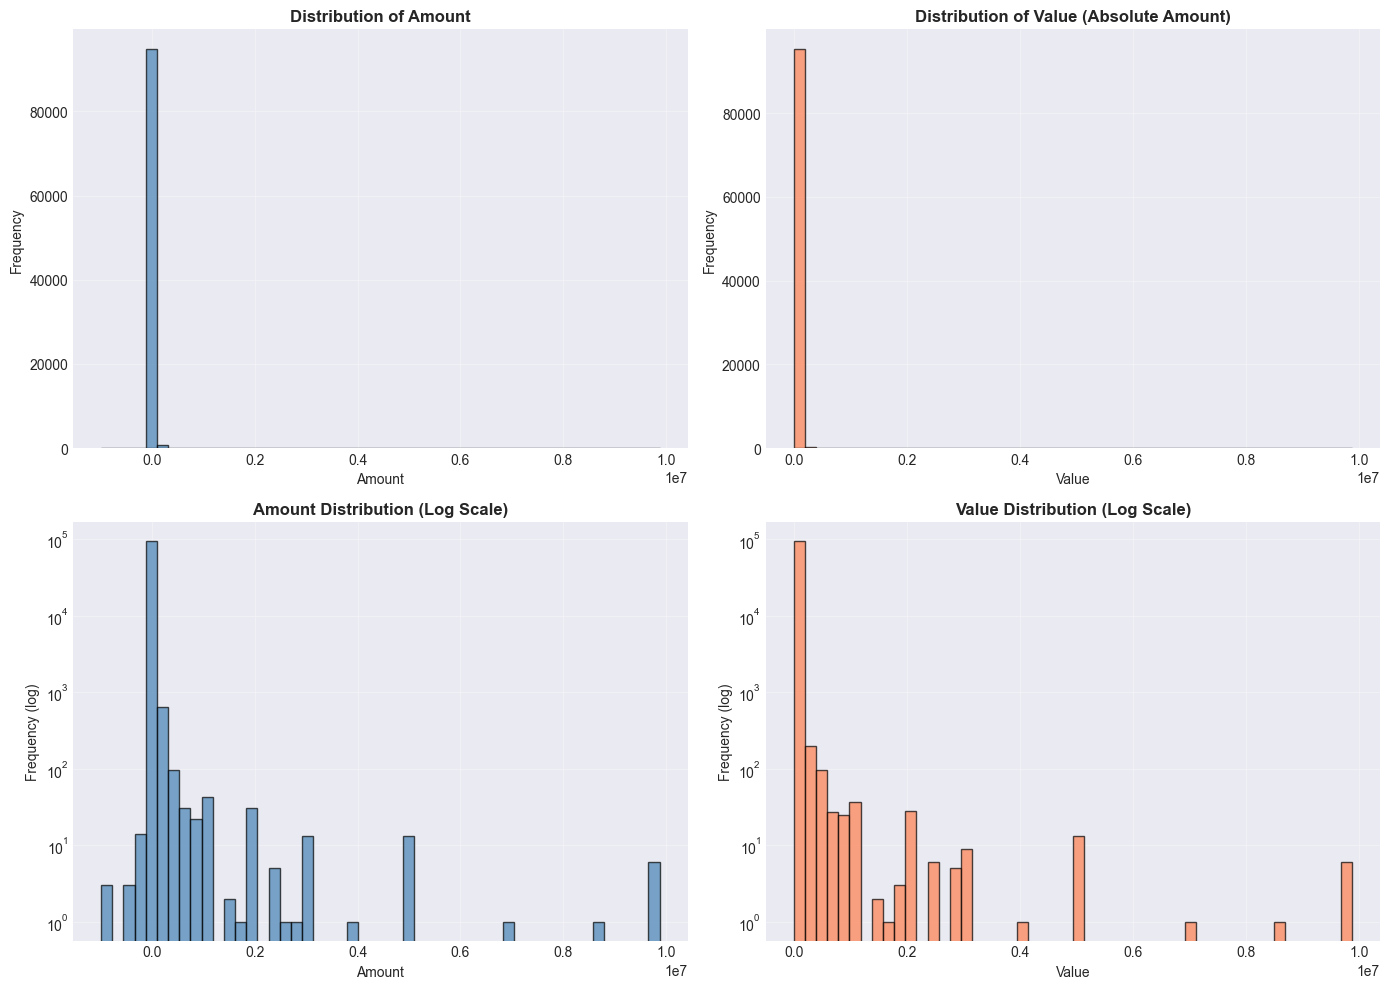


DISTRIBUTION STATISTICS - NUMERICAL FEATURES

CountryCode:
  Skewness: 0.0000 (Symmetric)
  Kurtosis: 0.0000
  Min: 256.00, Max: 256.00
  Q1: 256.00, Q3: 256.00

Amount:
  Skewness: 51.0985 (Right-skewed)
  Kurtosis: 3363.1277
  Min: -1000000.00, Max: 9880000.00
  Q1: -50.00, Q3: 2800.00

Value:
  Skewness: 51.2911 (Right-skewed)
  Kurtosis: 3378.0693
  Min: 2.00, Max: 9880000.00
  Q1: 275.00, Q3: 5000.00

PricingStrategy:
  Skewness: 1.6591 (Right-skewed)
  Kurtosis: 2.0875
  Min: 0.00, Max: 4.00
  Q1: 2.00, Q3: 2.00

FraudResult:
  Skewness: 22.1963 (Right-skewed)
  Kurtosis: 490.6858
  Min: 0.00, Max: 1.00
  Q1: 0.00, Q3: 0.00


In [27]:
# Distribution of Amount and Value
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution (histogram)
axes[0, 0].hist(df['Amount'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Distribution of Amount', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Value distribution (histogram)
axes[0, 1].hist(df['Value'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribution of Value (Absolute Amount)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Amount distribution (log scale)
axes[1, 0].hist(df['Amount'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Amount Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Amount')
axes[1, 0].set_ylabel('Frequency (log)')
axes[1, 0].grid(True, alpha=0.3)

# Value distribution (log scale)
axes[1, 1].hist(df['Value'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Value Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency (log)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness and Kurtosis
print("\n" + "=" * 80)
print("DISTRIBUTION STATISTICS - NUMERICAL FEATURES")
print("=" * 80)
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    skewness = df[col].skew()
    kurtosis_val = df[col].kurtosis()
    print(f"\n{col}:")
    print(f"  Skewness: {skewness:.4f} {'(Right-skewed)' if skewness > 0 else '(Left-skewed)' if skewness < 0 else '(Symmetric)'}")
    print(f"  Kurtosis: {kurtosis_val:.4f}")
    print(f"  Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")
    print(f"  Q1: {df[col].quantile(0.25):.2f}, Q3: {df[col].quantile(0.75):.2f}")

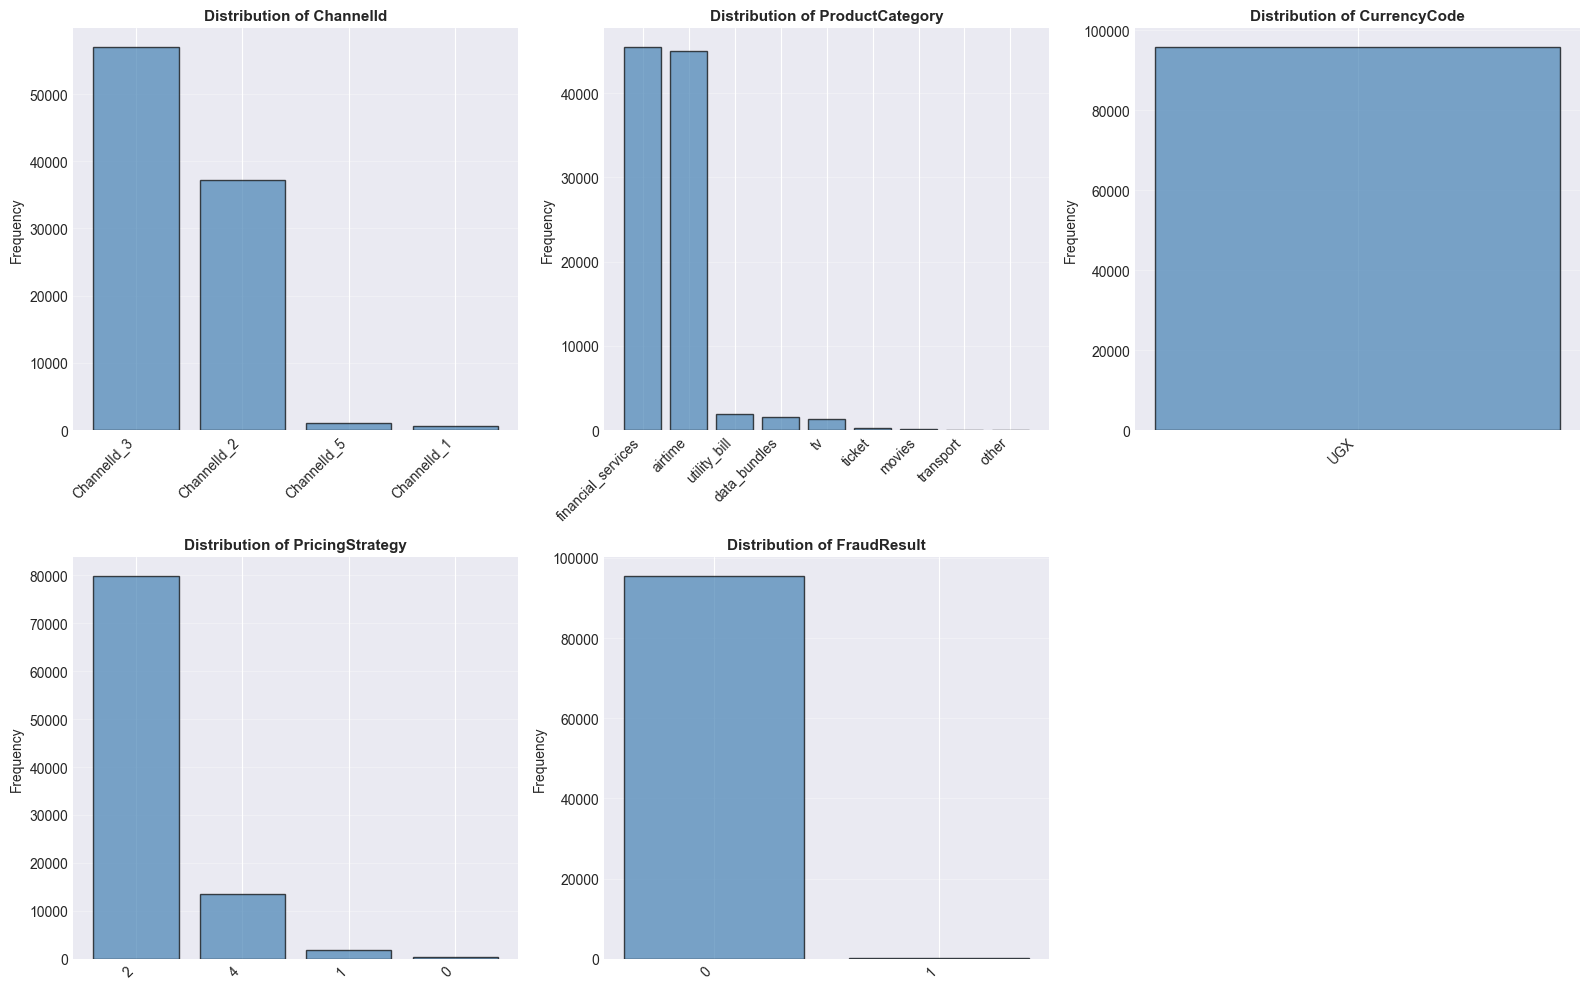


CATEGORICAL FEATURES ANALYSIS

ChannelId:
  Unique Values: 4
  Most Common: ChannelId_3 (56935 occurrences)
  Distribution:
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64

ProductCategory:
  Unique Values: 9
  Most Common: financial_services (45405 occurrences)
  Distribution:
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64

CurrencyCode:
  Unique Values: 1
  Most Common: UGX (95662 occurrences)
  Distribution:
CurrencyCode
UGX    95662
Name: count, dtype: int64

PricingStrategy:
  Unique Values: 4
  Most Common: 2 (79848 occurrences)
  Distribution:
PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64

FraudResult:
  Unique Values: 2
  Mo

In [28]:
# Categorical Features Distribution
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

categorical_viz = ['ChannelId', 'ProductCategory', 'CurrencyCode', 'PricingStrategy', 'FraudResult']

for idx, col in enumerate(categorical_viz[:5]):
    if col in df.columns:
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3, axis='y')

# Remove the last unused subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

# Detailed categorical analysis
print("\n" + "=" * 80)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

for col in categorical_viz:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique Values: {df[col].nunique()}")
        print(f"  Most Common: {df[col].value_counts().index[0]} ({df[col].value_counts().values[0]} occurrences)")
        print(f"  Distribution:")
        print(df[col].value_counts().head(10))

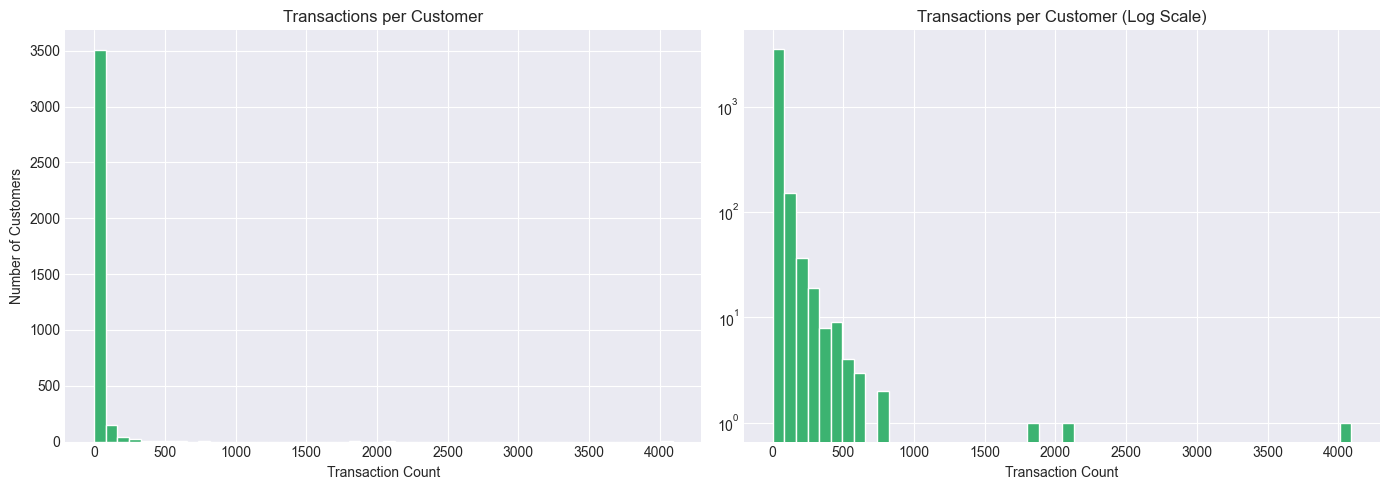

count    3742.00
mean       25.56
std        96.93
min         1.00
25%         2.00
50%         7.00
75%        20.00
max      4091.00
Name: TransactionId, dtype: float64


In [19]:
# Transactions per customer
tx_per_customer = df.groupby('CustomerId')['TransactionId'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(tx_per_customer, bins=50, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Transactions per Customer')
axes[0].set_xlabel('Transaction Count')
axes[0].set_ylabel('Number of Customers')

# Log scale to reveal long tail
axes[1].hist(tx_per_customer, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Transactions per Customer (Log Scale)')
axes[1].set_xlabel('Transaction Count')

plt.tight_layout()
plt.show()

print(tx_per_customer.describe().round(2))

## Section 5: Correlation Analysis

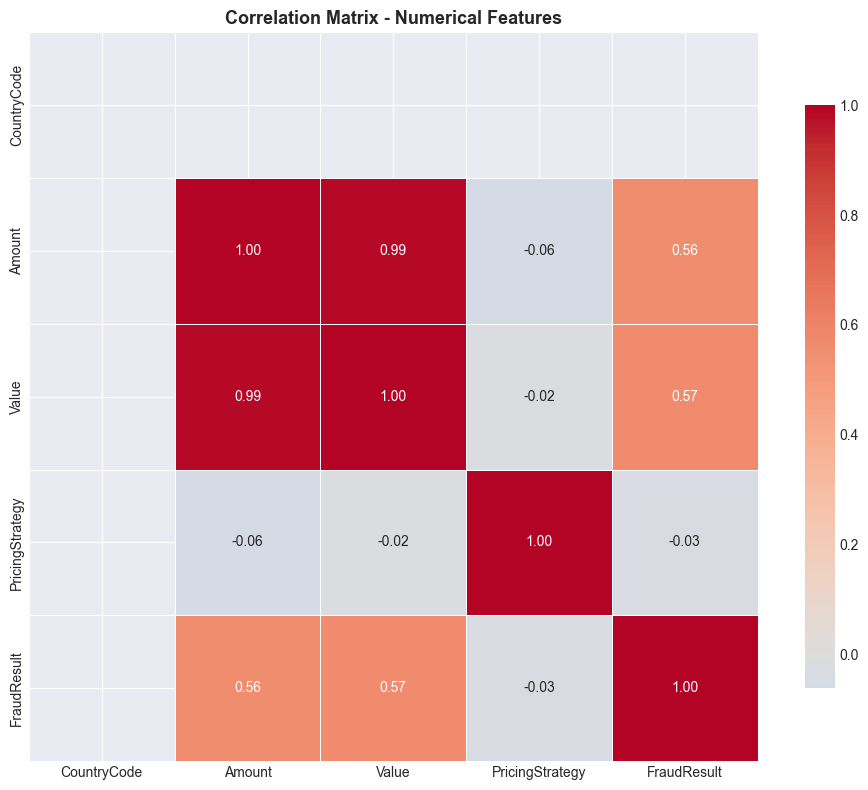


HIGH CORRELATIONS (|r| > 0.7)
Amount <-> Value: 0.9897

MODERATE CORRELATIONS (0.5 < |r| < 0.7)
Value <-> FraudResult: 0.5667
Amount <-> FraudResult: 0.5574


In [29]:
# Compute Correlation Matrix
numerical_df = df.select_dtypes(include=[np.number]).copy()
correlation_matrix = numerical_df.corr()

# Visualize Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify high correlations (excluding diagonal)
print("\n" + "=" * 80)
print("HIGH CORRELATIONS (|r| > 0.7)")
print("=" * 80)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} <-> {col2}: {corr:.4f}")
else:
    print("No high correlations found (|r| > 0.7)")

# Moderate correlations (0.5 to 0.7)
print("\n" + "=" * 80)
print("MODERATE CORRELATIONS (0.5 < |r| < 0.7)")
print("=" * 80)
moderate_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if 0.5 < corr_val < 0.7:
            moderate_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if moderate_corr_pairs:
    for col1, col2, corr in sorted(moderate_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"{col1} <-> {col2}: {corr:.4f}")
else:
    print("No moderate correlations found (0.5 < |r| < 0.7)")

## Section 6: Missing Values Assessment

In [10]:
# Comprehensive Missing Values Analysis
print("=" * 80)
print("MISSING VALUES DETAILED ANALYSIS")
print("=" * 80)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(4),
    'Data_Type': df.dtypes
})

missing_data = missing_data.sort_values('Missing_Count', ascending=False)
print(missing_data)

# Visualize missing data
if missing_data['Missing_Count'].sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_by_col = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
    
    ax.barh(missing_by_col['Column'], missing_by_col['Missing_Percentage'], color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Missing Percentage (%)', fontsize=11)
    ax.set_title('Missing Data Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values detected in the dataset!")

# Summary
print("\n" + "=" * 80)
print("MISSING VALUES SUMMARY")
print("=" * 80)
print(f"Total Cells: {df.shape[0] * df.shape[1]:,}")
print(f"Missing Cells: {df.isnull().sum().sum():,}")
print(f"Overall Missing Percentage: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.4f}%")
print(f"Columns with Missing Data: {(df.isnull().sum() > 0).sum()}")
print(f"Rows with Any Missing Data: {df.isnull().any(axis=1).sum()}")

MISSING VALUES DETAILED ANALYSIS
                                    Column  Missing_Count  Missing_Percentage  \
TransactionId                TransactionId              0                 0.0   
BatchId                            BatchId              0                 0.0   
AccountId                        AccountId              0                 0.0   
SubscriptionId              SubscriptionId              0                 0.0   
CustomerId                      CustomerId              0                 0.0   
CurrencyCode                  CurrencyCode              0                 0.0   
CountryCode                    CountryCode              0                 0.0   
ProviderId                      ProviderId              0                 0.0   
ProductId                        ProductId              0                 0.0   
ProductCategory            ProductCategory              0                 0.0   
ChannelId                        ChannelId              0                 0.

## Section 8: Key Insights Summary

### Top 5 Most Important EDA Findings

#### 1. **Dataset Composition and Scale**
- **95,662 transactions** from **3,742 unique customers** across **3,633 accounts**
- Transaction-level data spans exactly **90 days** (Nov 15, 2018 - Feb 13, 2019)
- **Single currency** (UGX - Uganda Shilling) and **single country** (CountryCode = 256) → Uganda-focused dataset
- Total transaction volume: **~642.6 million UGX** with average transaction of **6,717.85 UGX**
- **Action Items for Feature Engineering**: Aggregate transaction data by customer; create RFM metrics; extract temporal features from fixed 90-day window

#### 2. **Data Quality is Excellent - No Missing Values**
- **100% data completeness** across all 16 features
- All transactions have valid timestamps, amounts, and categorical attributes
- No imputation strategy needed; focus on feature engineering and scaling instead
- **Action Items**: Confirm timestamp parsing accuracy; validate amount/value relationship; check for data anomalies

#### 3. **Extremely Low Fraud Rate - NOT a Suitable Target**
- Fraud cases: **193 out of 95,662 (0.20%)** - severe class imbalance
- FraudResult shows **extreme positive skewness** (22.20) and high kurtosis (490.69)
- **CRITICAL**: 0.20% fraud rate is too sparse to train reliable credit risk models
- Fraud is distinct from credit risk; need independent proxy target variable via **RFM clustering**
- **Action Items**: 
  - Do NOT use FraudResult as target variable
  - Define high-risk customers through RFM segmentation (low frequency/monetary/recency)
  - Apply stratified clustering to create balanced risk tiers

#### 4. **Bidirectional Transactions with Extreme Outliers**
- **Negative amounts (Credits/Refunds)**: 38,189 transactions (39.92%)
- **Positive amounts (Debits/Charges)**: 57,473 transactions (60.08%)
- Amount range: **-1,000,000 to +9,880,000 UGX** → massive outliers exist
- **High positive skewness** (51.10) and extreme kurtosis (3,363.13) → log-normal distribution
- IQR method flags **25.55% as outliers** (legitimate high-value transactions, not data errors)
- Z-score method identifies **269 extreme outliers** (0.28%) by statistical definition
- **Action Items**:
  - Do NOT remove outliers; they represent legitimate high-value customers
  - Apply **log transformation** during feature engineering for normalization
  - Use **RobustScaler** instead of StandardScaler to handle extreme values
  - Create separate features for transaction direction (credits vs. debits)

#### 5. **Concentrated Distribution Across Key Business Segments**
- **ChannelId**: 4 channels with **dominant channel (ChannelId_3): 59.5%** of transactions; minority channels < 2% each
- **ProductCategory**: 9 categories dominated by:
  - Financial Services: **47.4%** of transactions
  - Airtime: **47.0%** of transactions
  - All others combined: **5.6%** (utility, data, TV, tickets, transport, etc.)
- **CurrencyCode**: Single currency (UGX) → no currency risk diversification
- **PricingStrategy**: 4 strategies with skewed distribution:
  - Strategy 2: **83.4%** (dominant)
  - Strategy 4: **14.2%**
  - Others: **2.4%** combined
- **Action Items**:
  - One-hot encode categorical features (ChannelId, ProductCategory, PricingStrategy)
  - Calculate RFM separately by channel and product category (behavioral segmentation)
  - Create dummy variables and aggregate features (count, sum, avg, std) per segment
  - Consider domain feature: high-value channels vs. niche channels for risk differentiation

### Additional Observations

**Strong Feature Correlations Identified**:
- **Amount ↔ Value**: r = 0.9897 → nearly perfect correlation, **drop one feature** (redundant)
- **Amount ↔ FraudResult**: r = 0.5574 → moderate positive correlation with fraud
- **Value ↔ FraudResult**: r = 0.5667 → slightly stronger with absolute amount
- **CountryCode**: Constant value (256) → **DROP** (no variance)
- **PricingStrategy ↔ Amount**: r = -0.06 → negligible correlation
- **Action Item**: Remove redundant/constant features before model training

**Recency Analysis Opportunity**:
- TransactionStartTime captured with full granularity (dates + timestamps)
- Fixed 90-day observation window enables accurate **Recency** (R) calculation
- Days since last transaction by customer → key engagement signal
- **Action Item**: Extract temporal features (day of week, hour, month); calculate days-since-last-tx

**Customer Behavioral Diversity**:
- Multiple transactions per customer suggest repeated purchase patterns
- Channel preference (ChannelId_3 dominance) indicates customer behavior clustering
- Financial services + airtime = 94.4% of volume → core business focus
- **Action Item**: Aggregate by customer across all transactions; preserve within-customer variance through std, count, etc.

### Recommendations for Next Steps

1. **Feature Engineering (Task 3)**:
   - **Aggregate to customer level**: count, sum, mean, std, min, max of amounts by channel/category
   - **RFM metrics**: Recency (days since last tx), Frequency (tx count), Monetary (sum of amounts)
   - **Temporal features**: Extract hour, day_of_week, month from TransactionStartTime
   - **Categorical encoding**: One-hot encode ProductCategory; label encode PricingStrategy
   - **Drop features**: CountryCode (constant), Value (redundant with Amount)
   - **Sign handling**: Separate credit vs. debit counts/amounts for bidirectional transactions

2. **Proxy Target Variable (Task 4)**:
   - Normalize RFM metrics (StandardScaler) to [0,1] scale
   - Apply **K-Means clustering** (k=3) on normalized RFM to identify risk segments
   - Label assignments:
     - **High Frequency + High Monetary + Recent** = Low-Risk (0)
     - **Medium engagement** = Medium-Risk (intermediate, may exclude)
     - **Low Frequency + Low Monetary + Inactive** = High-Risk (1)
   - Target should be balanced or use class weights in downstream model
   - Merge cluster labels back into customer-level feature dataset

3. **Model Development (Task 5)**:
   - **Handle imbalance**: Use `class_weight='balanced'` or SMOTE for minority class
   - **Candidate models**: Logistic Regression (interpretability), Gradient Boosting (performance)
   - **Baseline**: Logistic Regression with L2 regularization
   - **Advanced**: XGBoost/LightGBM with hyperparameter tuning
   - **Validation metrics**: Precision, Recall, F1-Score, ROC-AUC (not Accuracy due to imbalance)
   - **Feature importance**: Extract to identify key risk drivers for business stakeholders

4. **Risk Monitoring**:
   - Once deployed, track prediction calibration against actual defaults
   - Monitor feature drift (distribution shifts) and concept drift (target shift)
   - Implement retraining triggers based on performance degradation
   - Align model outputs with Basel II credit risk framework for regulatory compliance


---

## EDA Conclusion

This exploratory analysis reveals a **high-quality, well-structured transaction dataset** with **100% data completeness** and **clear patterns for credit risk feature engineering**. 

### Key Findings Summary:
**Data Quality**: Perfect completeness; no missing values; valid timestamps across 90-day window  
**Class Imbalance**: 0.20% fraud rate → insufficient for direct credit risk modeling (use RFM proxy instead)  
**Distribution**: Extreme positive skewness in amounts (log-normal); bidirectional transactions (39.92% credits)  
**Business Segments**: Concentrated in financial services (47.4%) and airtime (47.0%); 4 transaction channels  
**Correlations**: Amount ↔ Value perfectly correlated (r=0.99); moderate fraud correlation (r≈0.56); PricingStrategy uncorrelated  
**Outliers**: 25.55% flagged by IQR but legitimate high-value transactions; use log transformation + RobustScaler  


### Next Phase:
Transform transaction-level data into **customer-level RFM features**, define **credit risk proxy through K-Means clustering**, and train interpretable models aligned with **Basel II regulatory requirements for credit scoring**.


